In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin-1')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

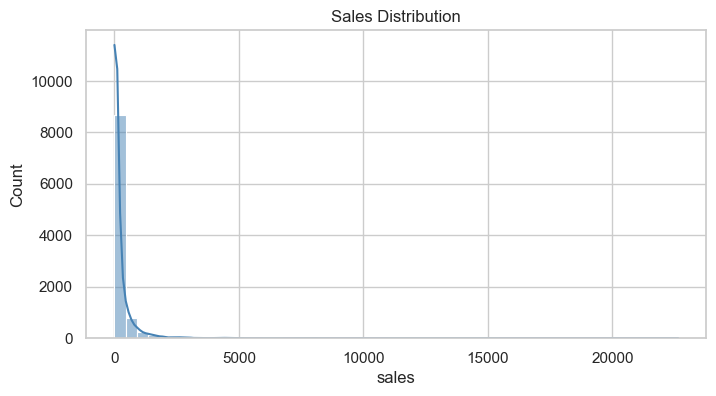

In [5]:
#Sales distribution
plt.figure(figsize=(8,4))
sns.histplot(df['sales'],bins=50,kde=True,color='steelblue')
plt.title('Sales Distribution')
plt.savefig('../visuals/sales_distribution.png',dpi=150,bbox_inches='tight')
plt.show()

Sales is heavily right-skewed. Most orders are under ₹1000 in value, but a few outliers go up to ₹22,000+. This means the business runs on high-volume small orders, not big-ticket deals.

C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_19420\2895042265.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales,x='category',y='sales',palette='Set2')


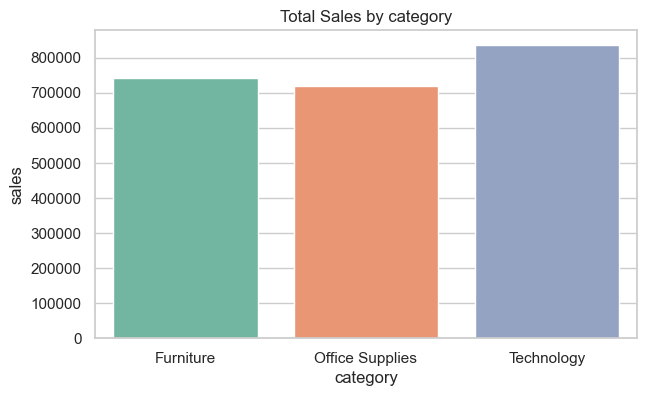

In [6]:
plt.figure(figsize=(7,4))
category_sales=df.groupby('category')['sales'].sum().reset_index()
sns.barplot(data=category_sales,x='category',y='sales',palette='Set2')
plt.title("Total Sales by category")
plt.savefig('../visuals/sales_by_category.png',dpi=150,bbox_inches='tight')
plt.show()

All three categories have similar total sales (~700K–840K). Technology leads slightly, but the gap is not dramatic. Sales alone is not a good performance metric here.

C:\Users\Mohammed Yousuf\AppData\Local\Temp\ipykernel_19420\2713582777.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_profit,x='category',y='profit',palette='Set1')


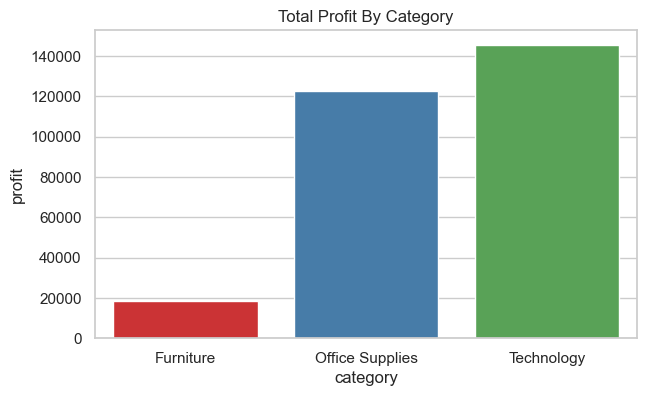

In [7]:
#Profit by Category
plt.figure(figsize=(7,4))
category_profit=df.groupby('category')['profit'].sum().reset_index()
sns.barplot(data=category_profit,x='category',y='profit',palette='Set1')
plt.title('Total Profit By Category')
plt.savefig('../visuals/profit_by_category.png',dpi=150,bbox_inches='tight')
plt.show()

This is the biggest insight. Furniture has ~18K profit despite ~740K in sales. That's barely a 2% margin. Technology and Office Supplies show 15–17% margins.

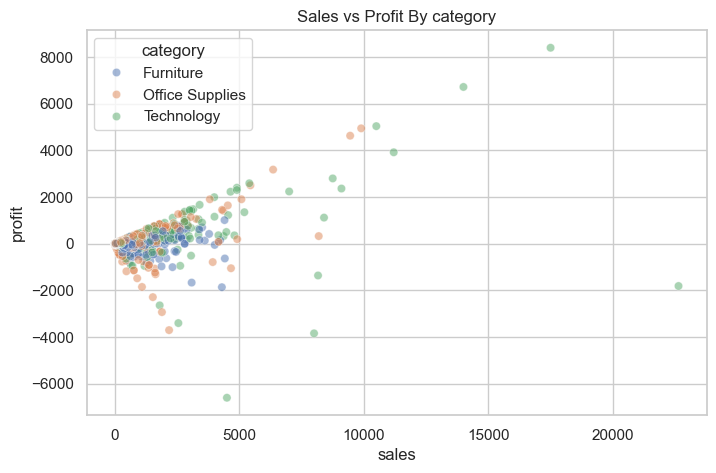

In [8]:
#Sales vs Profit scatter
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='sales',y='profit',hue='category',alpha=0.5)
plt.title('Sales vs Profit By category')
plt.savefig('../visuals/sales_vs_profit_by_category.png',dpi=150,bbox_inches='tight')
plt.show()

You can clearly see Furniture (blue) dots clustering near zero or below profit line despite decent sales values. Some orders show -6000 profit — those are loss-making orders, likely due to heavy discounts.

## 1.Which category is most profitable?
#### Technology, followed by Office Supplies. Furniture generates revenue but barely any profit — a classic discount abuse pattern.

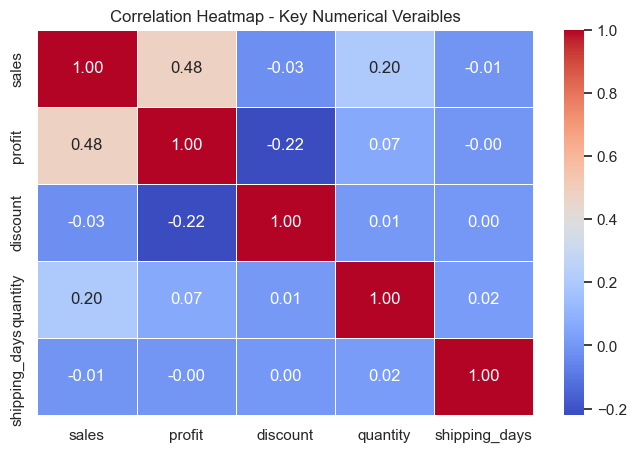

In [10]:
#Correlation Heatmap
plt.figure(figsize=(8,5))
corr=df[['sales','profit','discount','quantity','shipping_days']].corr()
sns.heatmap(corr,annot=True,fmt='.2f',cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap - Key Numerical Veraibles")
plt.savefig('../visuals/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()